In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## -- visit 1
c1, cerr1 = 1. - 0.73, 0.03
UPall1, UPerrall1 = 0.28, 0.13

# individuals
l2 = np.load('./data/contrasts/v1298tau_c_gaussiancontrasts.npz')
cs1 = l2['C1']
cserrs1 = l2['C1err']
UP1, UPerr1 = 0.29,0.05

cs2 = l2['C2']
cserrs2 = l2['C2err']
UP2, UPerr2 = 0.37,0.06

cs3 = l2['C3']
cserrs3 = l2['C3err']
UP3, UPerr3 = 0.87,0.2

cs4 = l2['C4']
cserrs4 = l2['C4err']
UP4, UPerr4 = 0.61,0.2

cs5 = l2['C5']
cserrs5 = l2['C5err']
UP5, UPerr5 = 0.34,0.13

cs6 = l2['C6']
cserrs6 = l2['C6err']
UP6, UPerr6 = 0.36,0.08

## -- visit 2
c2, cerr2 = 1. - 0.639, 0.004
UPall2, UPerrall2 = 0.30, 0.08

# individuals
l = np.load('./data/contrasts/V1298Taubd_gauss8_contrasts.npz')
waves = l['waves']
wavehws = l['wavehws']

cs7, cserrs7 = l['C7'], l['Cerr7']
UP7, UPerr7 = 0.243, 0.047

cs8, cserrs8 = l['C8'], l['Cerr8']
UP8, UPerr8 = 0.468, 0.099

cs9, cserrs9 = l['C9'], l['Cerr9']
UP9, UPerr9 = 0.176, 0.030

cs10, cserrs10 = l['C10'], l['Cerr10']
UP10, UPerr10 = 0.02, 0.459

cs12, cserrs12 = l['C12'], l['Cerr12']
UP12, UPerr12 = 0.276, 0.060

cs14, cserrs14 = l['C14'], l['Cerr14']
UP14, UPerr14 = 0.341, 0.062

## -- load Beck & Chapman (1993) data
bcy, bcx = np.loadtxt('./data/BC1993_table1.txt', skiprows=1, unpack=True)

In [3]:
## -- linear relations:

## -- Beck & Chapman 1993 relation
x_UP = np.linspace(0.05, 1.0, 25)
m_UP, merr_UP = 0.340, 0.058
b_UP, berr_UP = 0.220, 0.016
y_UP = b_UP + m_UP*x_UP

## -- visit 1
x_v1 = np.array([UP1,UP2,UP3,UP4,UP5,UP6])
xerr_v1 = np.array([UPerr1, UPerr2, UPerr3, UPerr4, UPerr5, UPerr6])
y_v1 = np.array([np.median(abs(cs1)),np.median(abs(cs2)),np.median(abs(cs3)),np.median(abs(cs4)),np.median(abs(cs5)),np.median(abs(cs6))])
yerr_v1 = np.array([np.median(cserrs1), np.median(cserrs2), np.median(cserrs3), np.median(cserrs4), np.median(cserrs5), np.median(cserrs6)])

m_v1, merr_v1 = 0.079, 0.076
b_v1, berr_v1 = 0.251, 0.033
yfit_v1 = x_UP*m_v1 + b_v1

## -- visit 2
x_v2 = np.array([UP7,UP8,UP9,UP12,UP14])
xerr_v2 = np.array([UPerr7, UPerr8, UPerr9, UPerr12, UPerr14])
y_v2 = np.array([np.median(cs7),np.median(cs8),np.median(cs9),np.median(cs12),np.median(cs14)])
yerr_v2 = np.array([np.median(cserrs7), np.median(cserrs8), np.median(cserrs9), np.median(cserrs12), np.median(cserrs14)])

m_v2, merr_v2 = 0.45, 0.07
b_v2, berr_v2 = 0.185, 0.022
yfit_v2 = x_UP*m_v2 + b_v2

In [4]:
def fit_errorband(x, m, b, merr, berr, N=1000):
    ytrue = m*x + b

    bands = np.zeros((len(x), int(N)))
    for i in range(N):
        mrand = np.random.normal(loc=m, scale=merr)
        brand = np.random.normal(loc=b, scale=berr)
        yrand = mrand*x + brand
        bands[:,i] = abs(yrand-ytrue)
    band_med = np.nanmedian(bands, axis=1)
    return band_med

In [5]:
## -- error visualizations
yfiterr_v1 = fit_errorband(x_UP, m_v1, b_v1, merr_v1, berr_v1, N=10000)
yfiterr_v2 = fit_errorband(x_UP, m_v2, b_v2, merr_v2, berr_v2, N=10000)
yfiterr_bc = fit_errorband(x_UP, m_UP, b_UP, merr_UP, berr_UP, N=10000)

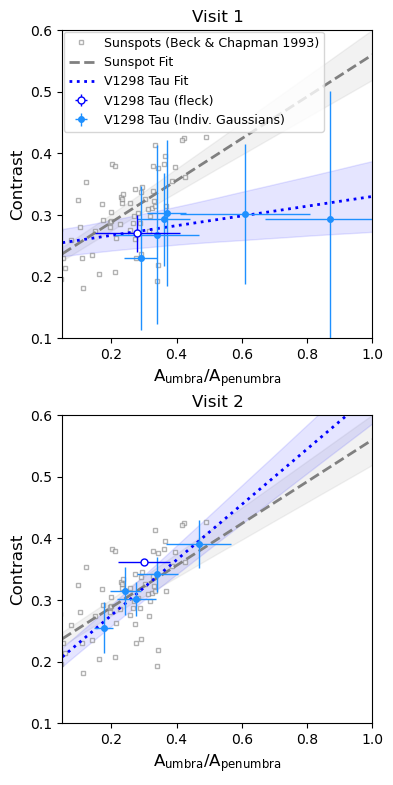

In [6]:
fig, ax = plt.subplots(figsize=(4,9), nrows=2)
plt.subplots_adjust(hspace=0.25)
# top: visit 1
ax[0].set_title('Visit 1', fontsize=12)

ax[0].plot(bcx, bcy, ls='None', marker='s', ms=3, c='gray', alpha=0.6, mfc='white', label='Sunspots (Beck & Chapman 1993)')

ax[0].fill_between(x_UP, y_UP-yfiterr_bc, y_UP+yfiterr_bc, ec='gray', fc='gray', alpha=0.1)
ax[0].plot(x_UP, y_UP, c='gray', lw=2, ls='--', label='Sunspot Fit')

ax[0].fill_between(x_UP, yfit_v1-yfiterr_v1, yfit_v1+yfiterr_v1, ec='blue', fc='blue', alpha=0.1)
ax[0].plot(x_UP, yfit_v1, c='blue', lw=2, ls='dotted', label='V1298 Tau Fit')

ax[0].errorbar(UPall1, c1, xerr=UPerrall1, yerr=cerr1, ls='None', lw=1, marker='o', ms=5, c='blue', mfc='white', zorder=10, label='V1298 Tau (fleck)')
ax[0].errorbar(x_v1, y_v1, xerr=xerr_v1, yerr=yerr_v1, ls='None', lw=1, marker='o', ms=4, c='dodgerblue', alpha=1, zorder=9, label='V1298 Tau (Indiv. Gaussians)')

ax[0].set_xlabel(r'A$_{\mathrm{umbra}}$/A$_{\mathrm{penumbra}}$', fontsize=12)
ax[0].set_ylabel('Contrast', fontsize=12)
ax[0].set_xlim(0.05,1.0)
ax[0].set_ylim(0.1,0.6)

# top: visit 2
ax[1].set_title('Visit 2', fontsize=12)

ax[1].plot(bcx, bcy, ls='None', marker='s', ms=3, c='gray', alpha=0.6, mfc='white', label='Sunspots (Beck & Chapman 1993)')

ax[1].fill_between(x_UP, y_UP-yfiterr_bc, y_UP+yfiterr_bc, ec='gray', fc='gray', alpha=0.1)
ax[1].plot(x_UP, y_UP, c='gray', lw=2, ls='--', label='Sunspot Fit')

ax[1].fill_between(x_UP, yfit_v2-yfiterr_v2, yfit_v2+yfiterr_v2, ec='blue', fc='blue', alpha=0.1)
ax[1].plot(x_UP, yfit_v2, c='blue', lw=2, ls='dotted', label='V1298 Tau Fit')

ax[1].errorbar(UPall2, c2, xerr=UPerrall2, yerr=cerr2, ls='None', lw=1, marker='o', ms=5, c='blue', mfc='white', zorder=10, label='V1298 Tau (fleck)')
ax[1].errorbar(x_v2, y_v2, xerr=xerr_v2, yerr=yerr_v2, ls='None', lw=1, marker='o', ms=4, c='dodgerblue', zorder=9, alpha=1, label='V1298 Tau (Indiv. Gaussians)')


ax[1].set_xlabel(r'A$_{\mathrm{umbra}}$/A$_{\mathrm{penumbra}}$', fontsize=12)
ax[1].set_ylabel('Contrast', fontsize=12)
ax[1].set_xlim(0.05,1.0)
ax[1].set_ylim(0.1,0.6)

ax[0].legend(loc=(0.004,0.67), fontsize=9)
plt.savefig('./figures/Figure9_contrast_vs_area.pdf', dpi=600, bbox_inches='tight')
plt.show()